数据统计信息:
  数据量: 633
  最小值: 0.0060
  最大值: 1.0230
  均值: 0.4569
  标准差: 0.1660

箱子设置:
  箱子宽度 (bin_width): 0.16
  箱子数量: 7
  箱子边界: [0.006      0.15128571 0.29657143 0.44185714 0.58714286 0.73242857
 0.87771429 1.023     ]


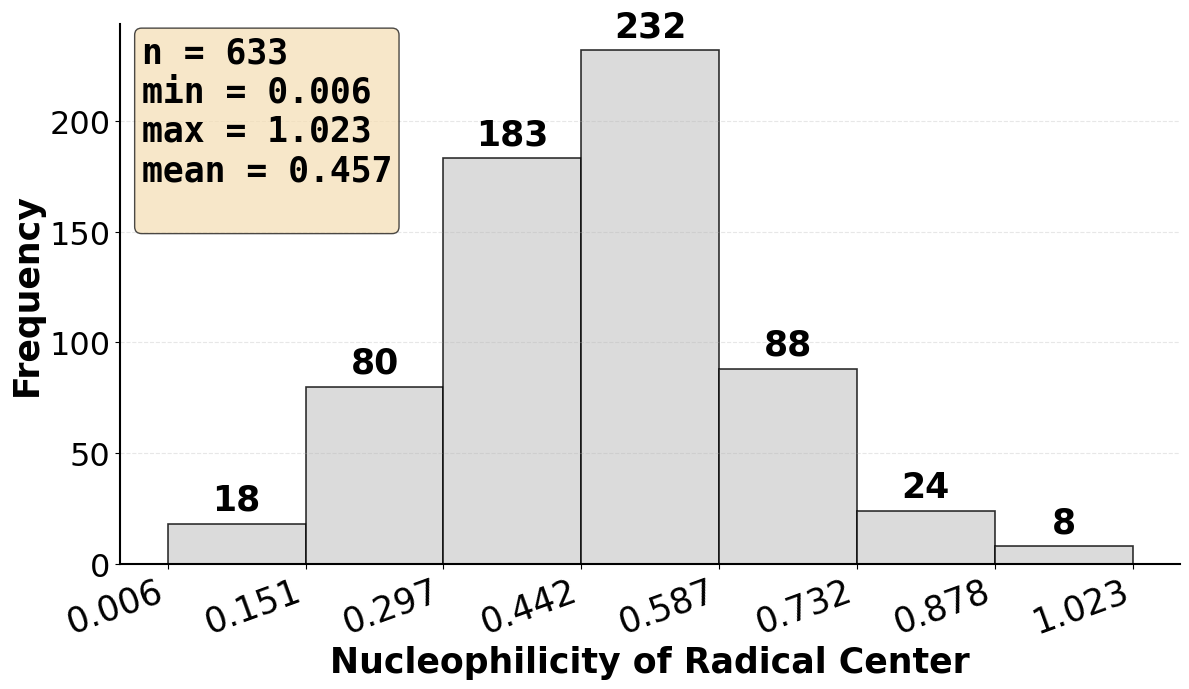


详细的箱子统计信息:
  箱子  1: [0.01, 0.15) - 频数:  18 - 占比:   2.8%
  箱子  2: [0.15, 0.30) - 频数:  80 - 占比:  12.6%
  箱子  3: [0.30, 0.44) - 频数: 183 - 占比:  28.9%
  箱子  4: [0.44, 0.59) - 频数: 232 - 占比:  36.7%
  箱子  5: [0.59, 0.73) - 频数:  88 - 占比:  13.9%
  箱子  6: [0.73, 0.88) - 频数:  24 - 占比:   3.8%
  箱子  7: [0.88, 1.02) - 频数:   8 - 占比:   1.3%

使用说明:
1. 要调整箱子数量，请修改代码中的 'bin_width' 变量。
2. 增大 bin_width 值（如 0.2, 0.3）会减少箱子数量。
3. 减小 bin_width 值（如 0.05, 0.1）会增加箱子数量。
4. 横坐标刻度已与每个箱子的边界对齐，可以直接读取每个箱子的取值范围。


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Read and load data ---
# Please replace the file path below with your actual path
file_path = (r"C:\Users\Lenovo\Desktop\ML-Electrophilicity\TrainingData\xyz_rdkitdescriptors.csv")
df = pd.read_csv(file_path)
data = df['fKN_def2QZVP'].values

# Diagnostics: Check data range
print(f"Data Statistics:")
print(f"  Data count: {len(data)}")
print(f"  Min value: {data.min():.4f}")
print(f"  Max value: {data.max():.4f}")
print(f"  Mean: {data.mean():.4f}")
print(f"  Std dev: {data.std():.4f}")

# --- 2. Set histogram bins ---
# Key: Control the number of bins by adjusting bin_width
# The larger the bin_width, the fewer the bins
bin_width = 0.16  # Modify here! Increase this value to reduce the number of bins, decrease to increase bins

data_min = data.min()
data_max = data.max()

# Calculate the approximate number of bins needed (round up to ensure full range coverage)
import math
num_bins = math.ceil((data_max - data_min) / bin_width)
# Key modification: Use linspace to ensure strictly starting from data_min and ending at data_max
bins = np.linspace(data_min, data_max, num_bins + 1)

print(f"\nBin Settings:")
print(f"  Bin width (bin_width): {bin_width}")
print(f"  Number of bins: {len(bins)-1}")
print(f"  Bin edges: {bins}")

# --- 3. Create figure and axis objects ---
fig, ax = plt.subplots(figsize=(12, 7))

# --- 4. Plot histogram ---
counts, edges, bars = ax.hist(data, 
                             bins=bins,           # Use manually defined bins
                             color='#D3D3D3',
                             edgecolor='black',
                             linewidth=1.2,
                             alpha=0.8)

# --- 5. Key Step: Set x-axis ticks to align with bin edges ---
# Set x-axis ticks to the boundary position of each bin
ax.set_xticks(edges)

# Set tick label format (keep 3 decimal places)
tick_labels = [f'{x:.3f}' for x in edges]
ax.set_xticklabels(tick_labels,  fontsize=25, rotation=20, ha="right" )

ax.tick_params(axis='y', labelsize=23)  # Modify the labelsize value here to adjust the y-axis number size

# --- 6. Add bar top labels (display frequency for each bin) ---
ax.bar_label(bars, fmt='%d', padding=5, fontsize=25, fontweight='bold')

# --- 7. Set axis labels and title ---
ax.set_xlabel("Nucleophilicity of Radical Center", fontsize=25, fontweight='bold')
ax.set_ylabel("Frequency", fontsize=25, fontweight='bold')

# --- 8. Add grid lines (y-axis direction, for easy reading of frequencies) ---
ax.grid(axis='y', alpha=0.3, linestyle='--')

# --- 9. Adjust axis appearance ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# --- 10. Set x-axis range, slightly expanded to show entirely ---
ax.set_xlim(edges[0] - 0.05, edges[-1] + 0.05)

# --- 11. Add statistics text box to the chart ---
stats_text = (f'n = {len(data)}\n'
              f'min = {data.min():.3f}\n'
              f'max = {data.max():.3f}\n'
              f'mean = {data.mean():.3f}\n'
              )
ax.text(0.02, 0.98, stats_text, 
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7,pad=0.2),
        fontweight='bold',fontsize=25, fontfamily='monospace')

# --- 12. Adjust layout and display ---
plt.tight_layout()
plt.show()

# --- 13. Print detailed bin information ---
print(f"\nDetailed Bin Statistics:")
for i in range(len(counts)):
    bin_start = edges[i]
    bin_end = edges[i+1]
    count = int(counts[i])
    percentage = (count / len(data)) * 100
    print(f"  Bin {i+1:2d}: [{bin_start:.2f}, {bin_end:.2f}) - Frequency: {count:3d} - Percentage: {percentage:5.1f}%")